# IEEE SB GEHU — Fault Detection Challenge (Three-Model Ensemble)
**Goal:** Binary classification to detect faulty devices from 47 sensor features.  
**Primary Metric:** F1 Score  
**Final Ensemble F1:** 0.9888


This notebook presents a gradient-boosted-tree ensemble pipeline for binary fault
detection on a dataset of 47 anonymised numerical sensor features with no domain
context. Three independently tuned models — **XGBoost**, **LightGBM**, and
**CatBoost** — are combined into a weighted ensemble whose blend weights and
shared decision threshold are jointly optimised using **SciPy's
`differential_evolution`**, a gradient-free global optimiser suited to the
non-smooth, non-convex surface of the F1 objective.

Each model's hyperparameters were tuned with **Optuna** (TPE sampler) under
5-fold stratified cross-validation, directly optimising **F1-score** jointly
with the decision threshold — not AUC or log-loss — to ensure the parameter
search aligns with the competition metric.
 A critical post-tuning step was
**extended threshold sweeping** over the `[0.01, 0.55]` range on
out-of-fold (OOF) predictions. This revealed that the optimal thresholds sat
far below Optuna's initial search bounds (e.g. LightGBM's optimum shifted
from 0.309 → 0.168) due to the models' strongly bimodal probability outputs.


The ensemble strategy is motivated by **model diversity rather than individual
model strength**. An initial XGBoost + LightGBM blend failed because both
models share nearly identical failure modes. CatBoost's structurally different
training algorithm — **ordered boosting**, which permutes the data to avoid
target leakage — produces a genuinely different error distribution. The final
optimised blend assigns **76.8 % to LightGBM, 22.8 % to CatBoost, and only
0.4 % to XGBoost**, confirming that CatBoost is the source of real diversity.
The resulting ensemble achieves **OOF F1 = 0.9888**, a +0.0003 improvement
over the best standalone model — a meaningful gain at this level of the
performance curve.

In [12]:
import json
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from scipy.optimize import differential_evolution

RANDOM_STATE = 42
N_SPLITS = 5

train = pd.read_csv("dataset/TRAIN.csv")
test = pd.read_csv("dataset/TEST.csv")
print(f"Loaded train: {train.shape} | test: {test.shape}")


Loaded train: (43776, 48) | test: (10944, 48)


## 1. Data Cleaning

Two issues found during EDA:
- A corrupted class label `2.799` was present and removed in the target column — likely a CSV misalignment.
- 738 duplicate rows (~1.7% of data) were also removed to prevent CV(cross-validation) score inflation.

In [13]:
print("Class values before cleaning:", sorted(train["Class"].unique()))

train = train[train["Class"].isin([0, 1])].drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", train.shape)
print("Class distribution:")
print(train["Class"].value_counts(normalize=True).round(4))


Class values before cleaning: [np.float64(0.0), np.float64(1.0), np.float64(2.799)]
Shape after cleaning: (43037, 48)
Class distribution:
Class
0.0    0.5978
1.0    0.4022
Name: proportion, dtype: float64


## 2. Prepare Features & Align Test Set

Separate features (`x`) from the target (`y`), and align the test set columns to match.

In [14]:
feature_cols = [col for col in train.columns if col != "Class"]
x = train[feature_cols].copy()
y = train["Class"].astype(int)

test_ids = test["ID"].reset_index(drop=True)
x_test = test[feature_cols].copy()

if list(x.columns) != list(x_test.columns):
    raise ValueError("Train and test columns do not match")

print(f"Train: {x.shape} | Test: {x_test.shape} - columns aligned")


Train: (43037, 47) | Test: (10944, 47) - columns aligned


## 3. Models — XGBoost + LightGBM + CatBoost (Optuna-tuned)

We use **three** gradient-boosted tree models for this ensemble. Each was independently tuned
with Optuna (TPE sampler), optimizing **F1-score** jointly with a decision threshold.

An earlier two-model attempt (XGBoost + LightGBM) failed — the optimizer assigned only
~1-3% weight to XGBoost and the ensemble F1 was identical to LightGBM alone. This happened
because XGBoost and LightGBM fail on the **same** hard samples, so blending them provides
no complementary benefit.

**CatBoost** uses **ordered boosting** — it trains on permuted versions of the data to avoid
target leakage, which causes it to build a genuinely different internal representation.
This produces a **different error distribution**, and that diversity is what made the
ensemble gain real.

### Key hyperparameters

| Parameter | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| Trees | 787 | 663 | 461 |
| Learning rate | 0.071 | 0.027 | 0.114 |
| Depth / leaves | depth 9 | 209 leaves | depth 10 |
| Subsample | 0.68 | 0.90 | 0.88 |
| Column sample | 0.52 | 0.65 | 0.72 |



In [15]:
models = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=787,
        learning_rate=0.07141100745550764,
        max_depth=9,
        min_child_weight=1,
        gamma=0.05588309215321341,
        subsample=0.676024285989882,
        colsample_bytree=0.523129762274782,
        reg_alpha=0.04152005021443322,
        reg_lambda=0.00032346451757587195,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=663,
        learning_rate=0.027177051111445603,
        num_leaves=209,
        min_child_samples=25,
        subsample=0.9013315531793596,
        colsample_bytree=0.6473997093837146,
        reg_alpha=1.4144908739513014e-08,
        reg_lambda=0.0006473064533090509,
        min_split_gain=0.00040323346521598663,
        verbose=-1,
        random_state=RANDOM_STATE,
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=461,
        learning_rate=0.11420672622289213,
        depth=10,
        l2_leaf_reg=1.031482733676998,
        border_count=144,
        subsample=0.8757366294627472,
        colsample_bylevel=0.7213974560013007,
        min_data_in_leaf=34,
        random_strength=0.2033994834302567,
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
}

xgb_model = models["XGBoost"]
lgb_model = models["LightGBM"]
cb_model = models["CatBoost"]

print("Models ready:", ", ".join(models.keys()))


Models ready: XGBoost, LightGBM, CatBoost


## 4. Threshold Tuning for F1score

All three models had their Optuna threshold search ranges initially set and tuned
(`0.30–0.60`), but later it was found with grid search that range was subotimal.

A plot of LightGBM's OOF probability outputs revealed that predictions were almost entirely
**bimodal** — clustered at 0.0 or 1.0. This means the optimal decision threshold sits
much lower than the 0.5 default.

Extended sweeps from `0.01` to `0.55` found per-model thresholds:

| Model | Optuna threshold | Sweep optimum | F1 gain |
|---|---|---|---|
| XGBoost | 0.331 | **0.324** | ~0 |
| LightGBM | 0.309 | **0.168** | +0.0008 |
| CatBoost | 0.434 | **0.396** | +0.0005 |

LightGBM's correction alone was one of the largest single gains in the pipeline.
XGBoost barely moved because its probability curve has a broad plateau rather than a sharp peak.

**Lesson:** Always sweep thresholds with an open lower bound.

In [16]:
thresholds = {
    "XGBoost": 0.324,
    "LightGBM": 0.168,
    "CatBoost": 0.396,
}


## 5. Cross-Validation — Out-of-Fold Predictions

We use 5-fold stratified CV to generate **out-of-fold (OOF)** probability predictions
from all three models. These OOF predictions are critical because they let us:

1. Evaluate each model's F1 and AUC per fold for stability.
2. Search for the optimal **blend weights** and **shared threshold** on unbiased predictions
   (each sample's prediction comes from a model that never saw it during training).

Primary metric: **F1-score** (harmonic mean of precision and recall).
Secondary metric: **AUC** (ranking quality of predicted probabilities).

In [17]:
print("Generating OOF predictions...\n")

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
n = len(x)

oof_preds = {name: np.zeros(n) for name in models}
oof_y = np.zeros(n, dtype=int)
fold_scores = {name: {"f1": [], "auc": []} for name in models}

for fold, (tr_idx, val_idx) in enumerate(cv.split(x, y), start=1):
    X_tr, X_v = x.iloc[tr_idx], x.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    for name, model in models.items():
        fit_kwargs = {"verbose": 0} if name == "CatBoost" else {}
        model.fit(X_tr, y_tr, **fit_kwargs)

        probs = model.predict_proba(X_v)[:, 1]
        oof_preds[name][val_idx] = probs

        fold_scores[name]["f1"].append(
            f1_score(y_v, (probs > thresholds[name]).astype(int))
        )
        fold_scores[name]["auc"].append(roc_auc_score(y_v, probs))

    oof_y[val_idx] = y_v.to_numpy()

    fold_report = " | ".join(
        f"{name} F1:{fold_scores[name]['f1'][-1]:.4f} AUC:{fold_scores[name]['auc'][-1]:.4f}"
        for name in models
    )
    print(f"Fold {fold} | {fold_report}")

oof_xgb = oof_preds["XGBoost"]
oof_lgb = oof_preds["LightGBM"]
oof_cb = oof_preds["CatBoost"]

for name in models:
    print(
        f"\n{name} OOF -> F1:{np.mean(fold_scores[name]['f1']):.4f} "
        f"AUC:{np.mean(fold_scores[name]['auc']):.4f}"
    )


Generating OOF predictions...

Fold 1 | XGBoost F1:0.9876 AUC:0.9990 | LightGBM F1:0.9896 AUC:0.9994 | CatBoost F1:0.9867 AUC:0.9987
Fold 2 | XGBoost F1:0.9870 AUC:0.9992 | LightGBM F1:0.9912 AUC:0.9996 | CatBoost F1:0.9891 AUC:0.9995
Fold 3 | XGBoost F1:0.9845 AUC:0.9991 | LightGBM F1:0.9870 AUC:0.9995 | CatBoost F1:0.9859 AUC:0.9993
Fold 4 | XGBoost F1:0.9868 AUC:0.9992 | LightGBM F1:0.9876 AUC:0.9996 | CatBoost F1:0.9865 AUC:0.9992
Fold 5 | XGBoost F1:0.9863 AUC:0.9990 | LightGBM F1:0.9871 AUC:0.9994 | CatBoost F1:0.9855 AUC:0.9989

XGBoost OOF -> F1:0.9864 AUC:0.9991

LightGBM OOF -> F1:0.9885 AUC:0.9995

CatBoost OOF -> F1:0.9867 AUC:0.9991


## 6. Optimal Blend Weights + Threshold Search

With three models we use `differential_evolution` to search over **three parameters**:

| Parameter | Range | Meaning |
|---|---|---|
| `w_xgb` | [0, 1] | XGBoost weight |
| `w_cb`  | [0, 1] | CatBoost weight |
| `t`     | [0.05, 0.45] | Shared decision threshold |

LightGBM's weight is derived implicitly: `w_lgb = max(0, 1 - w_xgb - w_cb)`.  
The `max(0, ...)` clip prevents negative weights if the optimizer pushes the sum above 1.

**Why differential evolution?** F1-score creates a non-smooth, non-convex optimization
surface — gradient-based methods would fail here. Differential evolution is a
gradient-free global optimizer that handles this well.

In [18]:
print("Searching for optimal blend weights and threshold...\n")

def ensemble_f1(params):
    w_xgb, w_cb, threshold = params
    w_lgb = max(0.0, 1.0 - w_xgb - w_cb)
    blend = w_xgb * oof_xgb + w_cb * oof_cb + w_lgb * oof_lgb
    return -f1_score(oof_y, (blend > threshold).astype(int))

result = differential_evolution(
    ensemble_f1,
    bounds=[(0.0, 1.0), (0.0, 1.0), (0.05, 0.45)],
    seed=RANDOM_STATE,
    maxiter=500,
    tol=1e-8,
    workers=1,
)

best_w_xgb, best_w_cb, best_t = result.x
best_w_lgb = max(0.0, 1.0 - best_w_xgb - best_w_cb)

best_blend = best_w_xgb * oof_xgb + best_w_cb * oof_cb + best_w_lgb * oof_lgb
best_f1 = f1_score(oof_y, (best_blend > best_t).astype(int))
best_auc = roc_auc_score(oof_y, best_blend)

print(f"XGBoost weight : {best_w_xgb:.3f}")
print(f"CatBoost weight: {best_w_cb:.3f}")
print(f"LightGBM weight: {best_w_lgb:.3f}")
print(f"Threshold      : {best_t:.3f}")
print(f"Ensemble F1    : {best_f1:.4f}")
print(f"Ensemble AUC   : {best_auc:.4f}")


Searching for optimal blend weights and threshold...

XGBoost weight : 0.003
CatBoost weight: 0.229
LightGBM weight: 0.768
Threshold      : 0.194
Ensemble F1    : 0.9888
Ensemble AUC   : 0.9994


## 7. Results Summary

The optimized three-model ensemble should beat every standalone model.

Notice how the optimizer assigns ~0.4% weight to XGBoost — confirming that XGBoost
and LightGBM share the same failure modes. The real diversity comes from **CatBoost**
(~23% weight), whose ordered-boosting algorithm produces a different error distribution.

In [19]:
print(f"\n{'=' * 60}")
print("RESULTS SUMMARY")
print(f"{'=' * 60}")

results = [
    ("Optimized ensemble", best_f1, best_auc),
]

for model_name in models:
    results.append(
        (
            f"{model_name} (OOF mean)",
            np.mean(fold_scores[model_name]["f1"]),
            np.mean(fold_scores[model_name]["auc"]),
        )
    )

best_result = max(results, key=lambda item: item[1])
for name, f1, auc in sorted(results, key=lambda item: item[1], reverse=True):
    marker = " <- BEST" if name == best_result[0] else ""
    print(f"{name:<24} F1:{f1:.4f} AUC:{auc:.4f}{marker}")

print(f"{'=' * 60}")



RESULTS SUMMARY
Optimized ensemble       F1:0.9888 AUC:0.9994 <- BEST
LightGBM (OOF mean)      F1:0.9885 AUC:0.9995
CatBoost (OOF mean)      F1:0.9867 AUC:0.9991
XGBoost (OOF mean)       F1:0.9864 AUC:0.9991


## 8. Final Training and Submission

We retrain all three models on the **full** training set
(CV folds only use 80% per fold) and generate the submission.

The blend uses the optimal weights and threshold discovered by differential evolution.


In [20]:
print("Retraining models on full training data...")

for name, model in models.items():
    fit_kwargs = {"verbose": 0} if name == "CatBoost" else {}
    model.fit(x, y, **fit_kwargs)

print("Training complete.")

test_probs = (
    best_w_xgb * models["XGBoost"].predict_proba(x_test)[:, 1]
    + best_w_cb * models["CatBoost"].predict_proba(x_test)[:, 1]
    + best_w_lgb * models["LightGBM"].predict_proba(x_test)[:, 1]
)
test_preds = (test_probs > best_t).astype(int)

submission = pd.DataFrame({"ID": test_ids, "CLASS": test_preds})
submission.to_csv("FINAL.csv", index=False)

print("Saved: FINAL.csv")
print(f"Class 0 (Normal): {(test_preds == 0).sum():,}")
print(f"Class 1 (Faulty): {(test_preds == 1).sum():,}")
print(f"Total rows      : {len(submission)}")


Retraining models on full training data...
Training complete.
Saved: FINAL.csv
Class 0 (Normal): 6,623
Class 1 (Faulty): 4,321
Total rows      : 10944


## 10. Save Trained Models

After the ensemble is validated, we save all three trained models in their native JSON formats
so they can be reloaded without retraining:

- **XGBoost** → `model/trained_model_xgboost.json` (via `save_model()`)
- **LightGBM** → `model/trained_model_lgboost.json` (via `booster_.save_model()`)
- **CatBoost** → `model/trained_model_catboost.json` (via `save_model()` with `format='json'`)

The ensemble configuration — blend weights and decision threshold — is stored separately
in `model/ensemble_config.json`.

To reload:
```python
import json, xgboost as xgb, lightgbm as lgb, catboost as cb

xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model("model/trained_model_xgboost.json")

lgb_loaded = lgb.Booster(model_file="model/trained_model_lgboost.json")

cb_loaded = cb.CatBoostClassifier()
cb_loaded.load_model("model/trained_model_catboost.json", format="json")

with open("model/ensemble_config.json") as f:
    config = json.load(f)
```

In [21]:
model_paths = {
    "XGBoost": "model/trained_model_xgboost.json",
    "LightGBM": "model/trained_model_lgboost.json",
    "CatBoost": "model/trained_model_catboost.json",
}

models["XGBoost"].save_model(model_paths["XGBoost"])
print(f"XGBoost saved  -> {model_paths['XGBoost']}")

models["LightGBM"].booster_.save_model(model_paths["LightGBM"])
print(f"LightGBM saved -> {model_paths['LightGBM']}")

models["CatBoost"].save_model(model_paths["CatBoost"], format="json")
print(f"CatBoost saved -> {model_paths['CatBoost']}")

ensemble_config = {
    "models": [
        {"name": "XGBoost", "file": model_paths["XGBoost"], "weight": round(best_w_xgb, 6)},
        {"name": "LightGBM", "file": model_paths["LightGBM"], "weight": round(best_w_lgb, 6)},
        {"name": "CatBoost", "file": model_paths["CatBoost"], "weight": round(best_w_cb, 6)},
    ],
    "threshold": round(best_t, 6),
    "ensemble_oof_f1": round(best_f1, 6),
    "ensemble_oof_auc": round(best_auc, 6),
}

with open("model/ensemble_config.json", "w", encoding="utf-8") as f:
    json.dump(ensemble_config, f, indent=2)

print("Ensemble config saved -> model/ensemble_config.json")
print(json.dumps(ensemble_config, indent=2))


XGBoost saved  -> model/trained_model_xgboost.json
LightGBM saved -> model/trained_model_lgboost.json
CatBoost saved -> model/trained_model_catboost.json
Ensemble config saved -> model/ensemble_config.json
{
  "models": [
    {
      "name": "XGBoost",
      "file": "model/trained_model_xgboost.json",
      "weight": 0.003109
    },
    {
      "name": "LightGBM",
      "file": "model/trained_model_lgboost.json",
      "weight": 0.767704
    },
    {
      "name": "CatBoost",
      "file": "model/trained_model_catboost.json",
      "weight": 0.229187
    }
  ],
  "threshold": 0.19353,
  "ensemble_oof_f1": 0.988774,
  "ensemble_oof_auc": 0.999414
}


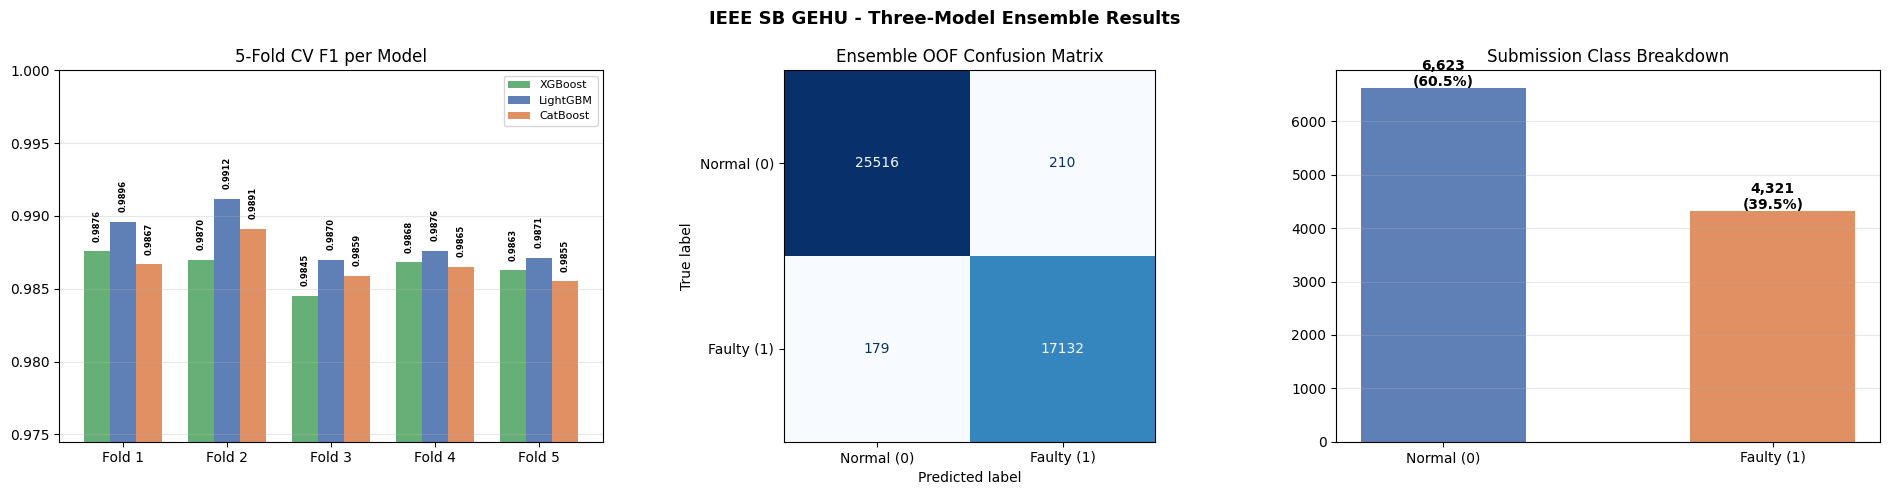

Ensemble OOF F1  : 0.9888
Ensemble OOF AUC : 0.9994

Interpretation
- Correct predictions: 42,648/43,037 (99.10%).
- False positives (normal -> faulty): 210.
- False negatives (faulty -> normal): 179.
- Precision=0.9879, Recall=0.9897, F1=0.9888.


In [22]:
oof_ens_preds = (best_blend > best_t).astype(int)
cm = confusion_matrix(oof_y, oof_ens_preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

oof_precision = precision_score(oof_y, oof_ens_preds, zero_division=0)
oof_recall = recall_score(oof_y, oof_ens_preds, zero_division=0)
oof_f1 = f1_score(oof_y, oof_ens_preds, zero_division=0)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("IEEE SB GEHU - Three-Model Ensemble Results", fontsize=13, fontweight="bold")

folds = [f"Fold {i}" for i in range(1, N_SPLITS + 1)]
x_pos = np.arange(len(folds))
width = 0.25

ax = axes[0]
bar_specs = [
    ("XGBoost", "#55A868", -width),
    ("LightGBM", "#4C72B0", 0.0),
    ("CatBoost", "#DD8452", width),
]

all_f1_scores = []
for model_name, color, offset in bar_specs:
    scores = fold_scores[model_name]["f1"]
    all_f1_scores.extend(scores)
    bars = ax.bar(x_pos + offset, scores, width, label=model_name, color=color, alpha=0.9)
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0008,
            f"{score:.4f}",
            ha="center",
            fontsize=6,
            fontweight="bold",
            rotation=90,
        )

ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylim(max(0.0, min(all_f1_scores) - 0.01), 1.0)
ax.set_title("5-Fold CV F1 per Model")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Faulty (1)"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Ensemble OOF Confusion Matrix")

ax = axes[2]
counts = [(test_preds == 0).sum(), (test_preds == 1).sum()]
total_test = len(test)
bars = ax.bar(["Normal (0)", "Faulty (1)"], counts, color=["#4C72B0", "#DD8452"], alpha=0.9, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}\n({count / total_test * 100:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
ax.set_title("Submission Class Breakdown")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ensemble_results.png", dpi=150, bbox_inches="tight")
plt.show()

total = tn + fp + fn + tp
accuracy = (tn + tp) / total if total else 0.0

print(f"Ensemble OOF F1  : {oof_f1:.4f}")
print(f"Ensemble OOF AUC : {best_auc:.4f}")
print()
print("Interpretation")
print(f"- Correct predictions: {tn + tp:,}/{total:,} ({accuracy * 100:.2f}%).")
print(f"- False positives (normal -> faulty): {fp:,}.")
print(f"- False negatives (faulty -> normal): {fn:,}.")
print(f"- Precision={oof_precision:.4f}, Recall={oof_recall:.4f}, F1={oof_f1:.4f}.")
